# Análisis exploratorio de los datos (EDA)
En este notebook haremos una auditoría exhaustiva del dataset Online Retail. A través de él revisaremos la integridad de los datos y detectaremos posibles anomalías antes de pasar a la limpieza. Para que el análisis sea más visual e intuitivo, apoyaremos las conclusiones con gráficos específicos.

## 1. Imports y Carga del Dataset

Lo que hemos realizado en este fragmento de código el cual preparamos el entorno de trabajo para realizar un análisis de datos profesional, encargándonos de importar las librerías necesarias (Pandas, NumPy, Matplotlib y Seaborn), configurar una estética visual uniforme para los gráficos y gestionar la estructura de carpetas del proyecto. La función principal es establecer las rutas de los archivos de datos y asegurarnos que el directorio de salida para las imágenes exista, dejando todo listo para procesar información y generar visualizaciones de forma organizada.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Configuración visual global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
%matplotlib inline

# Rutas
RUTA_CSV      = '../../../data/raw/data.csv'
RUTA_GRAFICOS = '../../../graphics/'
os.makedirs(RUTA_GRAFICOS, exist_ok=True)

print('Librerías cargadas correctamente.')

In [ ]:
df = pd.read_csv(RUTA_CSV, encoding='latin-1')

# ── Dimensiones ───────────────────────────────────────────────────────────────
print('=' * 55)
print(f'  DATASET CARGADO')
print('=' * 55)
print(f'  Filas    : {df.shape[0]:>10,}')
print(f'  Columnas : {df.shape[1]:>10}')
print('=' * 55)

# ── Tipos de datos ────────────────────────────────────────────────────────────
print('\n── Tipos de datos ──')
print(df.dtypes.to_string())

# ── Primeras filas ────────────────────────────────────────────────────────────
print('\n── Primeras 5 filas ──')
display(df.head())

# ── Información general ───────────────────────────────────────────────────────
print('\n── Información general ──')
df.info()

# ── Estadísticas descriptivas ─────────────────────────────────────────────────
print('\n── Estadísticas descriptivas ──')
display(df.describe().round(2))

## 2. Análisis exploratorio de los datos (EDA)

### 2.1 Entendimiento de los datos

Exploramos dimensiones, tipos, valores únicos y estadísticas descriptivas. También identificamos transacciones con cantidades o precios negativos/cero, que en este dominio pueden corresponder a **devoluciones, regalos o ajustes contables**.

In [ ]:
print('--- 2.1.1 Dimensiones y tipos de datos ---')
print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
print('\nTipos de datos por columna:')
print(df.dtypes)

In [ ]:
print('--- 2.1.2 Primeras 10 filas ---')

display(df.head(10))

print('\n--- 2.1.3 Últimas 10 filas ---')

display(df.tail(10))

In [ ]:
print('--- 2.1.4 Valores únicos por columna ---')

for col in df.columns:
    print(f'  {col}: {df[col].nunique():,} valores únicos')

print('\n--- 2.1.5 Muestra de valores únicos (columnas categóricas) ---')

columnas_categoricas = ['InvoiceNo', 'StockCode', 'Description', 'Country']
for col in columnas_categoricas:
    muestra = df[col].dropna().unique()[:10]
    print(f'\n  {col} (primeros 10 únicos):')
    print(f'  {muestra}')

In [ ]:
print('--- 2.1.6 Estadísticas descriptivas (columnas numéricas) ---')

df.describe()

In [ ]:
print('--- 2.1.7 Transacciones con Quantity <= 0 ---')

trans_qty_negativa = df[df['Quantity'] <= 0]
print(f'  Total filas con Quantity <= 0: {len(trans_qty_negativa):,}')
print(f'  % sobre total: {len(trans_qty_negativa) / len(df) * 100:.2f}%')
display(trans_qty_negativa[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice']].head(10))

print('\n--- 2.1.8 Transacciones con UnitPrice <= 0 ---')

trans_price_negativa = df[df['UnitPrice'] <= 0]
print(f'  Total filas con UnitPrice <= 0: {len(trans_price_negativa):,}')
print(f'  % sobre total: {len(trans_price_negativa) / len(df) * 100:.2f}%')
display(trans_price_negativa[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice']].head(10))

### 2.2 Valores faltantes, duplicados y erróneos

Usamos `isnull`, `duplicated` y `value_counts` para cuantificar los problemas de calidad del dato:
- **CustomerID nulo**: transacciones anónimas (sin cliente registrado).
- **Description nula**: líneas de factura sin descripción de producto.
- **Filas duplicadas**: registros idénticos en todas sus columnas.
- **StockCodes no estándar**: códigos que no siguen el patrón `[0-9],[A-Za-z]`.

In [ ]:
# 2.2.1 — Resumen de valores faltantes por columna
nulos     = df.isnull().sum()
nulos_pct = nulos / len(df) * 100
resumen_nulos = pd.DataFrame({'Nulos': nulos, '% sobre total': nulos_pct.round(2)})

print('── 2.2.1 Valores faltantes (NaN) por columna ──')
display(resumen_nulos[resumen_nulos['Nulos'] > 0])

In [ ]:
# [DOC] Procederemos a crear una visualización que nos detecte los datos faltantes. Los colores claros indican la ausencia de datos (nulos).

plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='magma')
plt.title('Distribución de Valores Nulos (En colores claro lo que falta)')
plt.show()

print("\n[INFO] Conteo exacto de nulos:")
print(df.isnull().sum()[df.isnull().sum() > 0])

In [ ]:
# 2.2.2 — Filas sin CustomerID
sin_cliente = df[df['CustomerID'].isnull()]

print('── 2.2.2 Filas sin CustomerID ──')
print(f'  Total   : {len(sin_cliente):,}')
print(f'  % total : {len(sin_cliente) / len(df) * 100:.2f}%')
print('\n  Distribución por país (top 10):')
print(sin_cliente['Country'].value_counts().head(10).to_string())

In [ ]:
# 2.2.3 — Filas sin Description
sin_descripcion = df[df['Description'].isnull()]

print('── 2.2.3 Filas sin Description ──')
print(f'  Total   : {len(sin_descripcion):,}')
print(f'  % total : {len(sin_descripcion) / len(df) * 100:.2f}%')
display(sin_descripcion[['InvoiceNo', 'StockCode', 'Quantity', 'UnitPrice', 'CustomerID']].head(10))

# 2.2.4 — Sin CustomerID y sin Description simultáneamente
sin_ambos = df[df['CustomerID'].isnull() & df['Description'].isnull()]
print('\n── 2.2.4 Sin CustomerID y sin Description simultáneamente ──')
print(f'  Total : {len(sin_ambos):,}')

In [ ]:
# 2.2.5 — Filas duplicadas (exactas en todas las columnas)
duplicados = df.duplicated()

print('── 2.2.5 Filas duplicadas ──')
print(f'  Total     : {duplicados.sum():,}')
print(f'  % total   : {duplicados.sum() / len(df) * 100:.2f}%')
print('\n  Muestra de duplicados:')
display(df[duplicados].head(10))

In [ ]:
# 2.2.6 — Formato de InvoiceDate (actualmente string)
print('── 2.2.6 Formato de InvoiceDate ──')
print(f'  Tipo actual : {df["InvoiceDate"].dtype}')
print('\n  Muestra de valores:')
print(df['InvoiceDate'].value_counts().head(10).to_string())
print(f'\n  Min : {df["InvoiceDate"].min()}')
print(f'  Max : {df["InvoiceDate"].max()}')

In [ ]:
# 2.2.7 — StockCodes no estándar (patrón: 5 dígitos + letra opcional)
stock_no_estandar = df[~df['StockCode'].str.match(r'^[0-9]{5}[A-Za-z]?$', na=False)]

print('── 2.2.7 StockCodes no estándar ──')
print(f'  Total filas afectadas : {len(stock_no_estandar):,}')
print(f'  % sobre total         : {len(stock_no_estandar) / len(df) * 100:.2f}%')
print('\n  Tipos de StockCodes no estándar (top 15):')
print(stock_no_estandar['StockCode'].value_counts().head(15).to_string())

In [ ]:
# 2.2.8 — Distribución de Country (value_counts)
print('── 2.2.8 Distribución de Country ──')
print(df['Country'].value_counts().to_string())

### 2.3 Búsqueda de outliers

Aplicamos el **método IQR** (rango intercuartílico) tanto a `Quantity` como a `UnitPrice` para identificar valores extremos que podrían distorsionar el modelo. Como regla general, esperamos que el **90–95 % de los datos queden dentro del rango normal**.

$$\text{Límite inferior} = Q1 - 1{,}5 \cdot IQR \qquad \text{Límite superior} = Q3 + 1{,}5 \cdot IQR$$

In [34]:
# 2.3.1 — Outliers en Quantity (método IQR)
Q1_qty  = df['Quantity'].quantile(0.25)
Q3_qty  = df['Quantity'].quantile(0.75)
IQR_qty = Q3_qty - Q1_qty
lim_inf_qty = Q1_qty - 1.5 * IQR_qty
lim_sup_qty = Q3_qty + 1.5 * IQR_qty
outliers_qty = df[(df['Quantity'] < lim_inf_qty) | (df['Quantity'] > lim_sup_qty)]

print('── 2.3.1 Outliers en Quantity (método IQR) ──')
print(f'  Q1={Q1_qty} | Q3={Q3_qty} | IQR={IQR_qty}')
print(f'  Límite inferior : {lim_inf_qty:.2f}')
print(f'  Límite superior : {lim_sup_qty:.2f}')
print(f'  Total outliers  : {len(outliers_qty):,} ({len(outliers_qty) / len(df) * 100:.2f}%)')
print('\n  Top 5 mayores:')
display(df.nlargest(5, 'Quantity')[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice']])
print('\n  Top 5 menores:')
display(df.nsmallest(5, 'Quantity')[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice']])

── 2.3.1 Outliers en Quantity (método IQR) ──
  Q1=1.0 | Q3=10.0 | IQR=9.0
  Límite inferior : -12.50
  Límite superior : 23.50
  Total outliers  : 58,619 (10.82%)

  Top 5 mayores:


,InvoiceNo,StockCode,Description,Quantity,UnitPrice
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,0.00
74614,542504,37413,NaN,5568,0.00
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21



  Top 5 menores:


,InvoiceNo,StockCode,Description,Quantity,UnitPrice
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2.08
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1.04
225529,556690,23005,printing smudges/thrown away,-9600,0.00
225530,556691,23005,printing smudges/thrown away,-9600,0.00
4287,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,0.03


In [35]:
# 2.3.2 — Outliers en UnitPrice (método IQR)
Q1_price  = df['UnitPrice'].quantile(0.25)
Q3_price  = df['UnitPrice'].quantile(0.75)
IQR_price = Q3_price - Q1_price
lim_inf_price = Q1_price - 1.5 * IQR_price
lim_sup_price = Q3_price + 1.5 * IQR_price
outliers_price = df[(df['UnitPrice'] < lim_inf_price) | (df['UnitPrice'] > lim_sup_price)]

print('── 2.3.2 Outliers en UnitPrice (método IQR) ──')
print(f'  Q1={Q1_price:.4f} | Q3={Q3_price:.4f} | IQR={IQR_price:.4f}')
print(f'  Límite inferior : {lim_inf_price:.2f}')
print(f'  Límite superior : {lim_sup_price:.2f}')
print(f'  Total outliers  : {len(outliers_price):,} ({len(outliers_price) / len(df) * 100:.2f}%)')
print('\n  Top 5 precios más altos:')
display(df.nlargest(5, 'UnitPrice')[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice']])

── 2.3.2 Outliers en UnitPrice (método IQR) ──
  Q1=1.2500 | Q3=4.1300 | IQR=2.8800
  Límite inferior : -3.07
  Límite superior : 8.45
  Total outliers  : 39,627 (7.31%)

  Top 5 precios más altos:


,InvoiceNo,StockCode,Description,Quantity,UnitPrice
222681,C556445,M,Manual,-1,38970.00
524602,C580605,AMAZONFEE,AMAZON FEE,-1,17836.46
43702,C540117,AMAZONFEE,AMAZON FEE,-1,16888.02
43703,C540118,AMAZONFEE,AMAZON FEE,-1,16453.71
15016,C537630,AMAZONFEE,AMAZON FEE,-1,13541.33


In [36]:
# 2.3.3 / 2.3.4 — Outliers categóricos: StockCodes y Descriptions poco frecuentes
stock_freq  = df['StockCode'].value_counts()
stock_raros = stock_freq[stock_freq <= 3]

print('── 2.3.3 StockCodes con ≤ 3 apariciones ──')
print(f'  Total : {len(stock_raros):,}')
print(stock_raros.head(10).to_string())

desc_freq  = df['Description'].value_counts()
desc_raras = desc_freq[desc_freq <= 3]

print('\n── 2.3.4 Descriptions con ≤ 3 apariciones ──')
print(f'  Total : {len(desc_raras):,}')
print(desc_raras.head(10).to_string())

── 2.3.3 StockCodes con ≤ 3 apariciones ──
  Total : 459
StockCode
20820     3
21895     3
22145     3
37461     3
21594     3
84856L    3
90024C    3
90077     3
35271S    3
21538     3

── 2.3.4 Descriptions con ≤ 3 apariciones ──
  Total : 583
Description
PINK CHRISTMAS FLOCK DROPLET         3
NEW BAROQUE B'FLY NECKLACE GREEN     3
BLACK DIAMOND CLUSTER EARRINGS       3
SET/4 GARDEN ROSE DINNER CANDLE      3
HEARTS WRAPPING TAPE                 3
VINTAGE PHOTO ALBUM PARIS DAYS       3
PINK/WHITE RIBBED MELAMINE JUG       3
GLITTER SNOW PEAR TREE DECORATION    3
GINGHAM OVEN GLOVE RED HEART         3
FOLKART ZINC STAR CHRISTMAS DEC      3


In [37]:
# 2.3.5 / 2.3.6 — Distribución por percentiles
percentiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.0]

print('── 2.3.5 Distribución de Quantity por percentiles ──')
print(df['Quantity'].quantile(percentiles).to_string())

print('\n── 2.3.6 Distribución de UnitPrice por percentiles ──')
print(df['UnitPrice'].quantile(percentiles).to_string())

── 2.3.5 Distribución de Quantity por percentiles ──
0.01       -2.0
0.05        1.0
0.25        1.0
0.50        3.0
0.75       10.0
0.95       29.0
0.99      100.0
1.00    80995.0

── 2.3.6 Distribución de UnitPrice por percentiles ──
0.01        0.19
0.05        0.42
0.25        1.25
0.50        2.08
0.75        4.13
0.95        9.95
0.99       18.00
1.00    38970.00


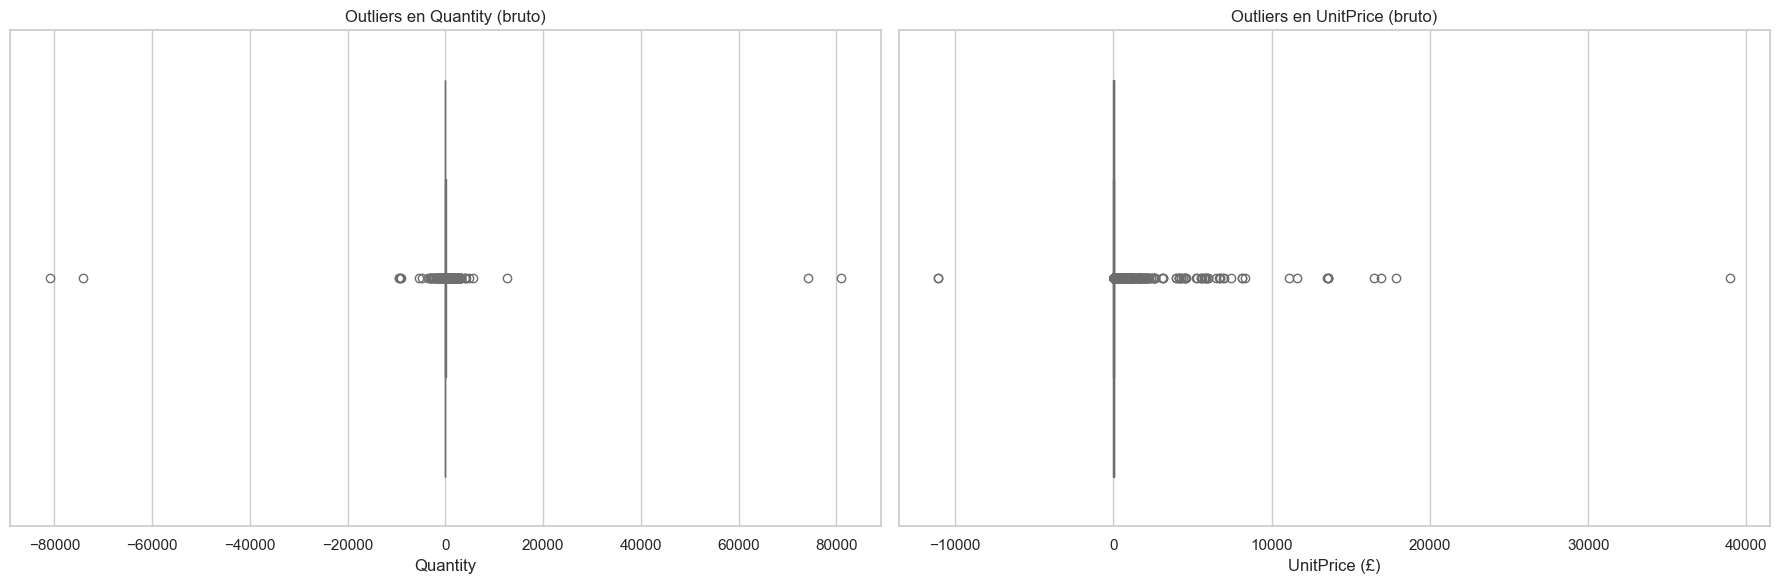

In [38]:
# 2.3.7 — Boxplots brutos de Quantity y UnitPrice (datos sin filtrar)
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(x=df['Quantity'], ax=ax[0], color='skyblue')
ax[0].set_title('Outliers en Quantity (bruto)')
ax[0].set_xlabel('Quantity')

sns.boxplot(x=df['UnitPrice'], ax=ax[1], color='salmon')
ax[1].set_title('Outliers en UnitPrice (bruto)')
ax[1].set_xlabel('UnitPrice (£)')

plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.3.7_boxplots_brutos.png', dpi=150)
plt.show()

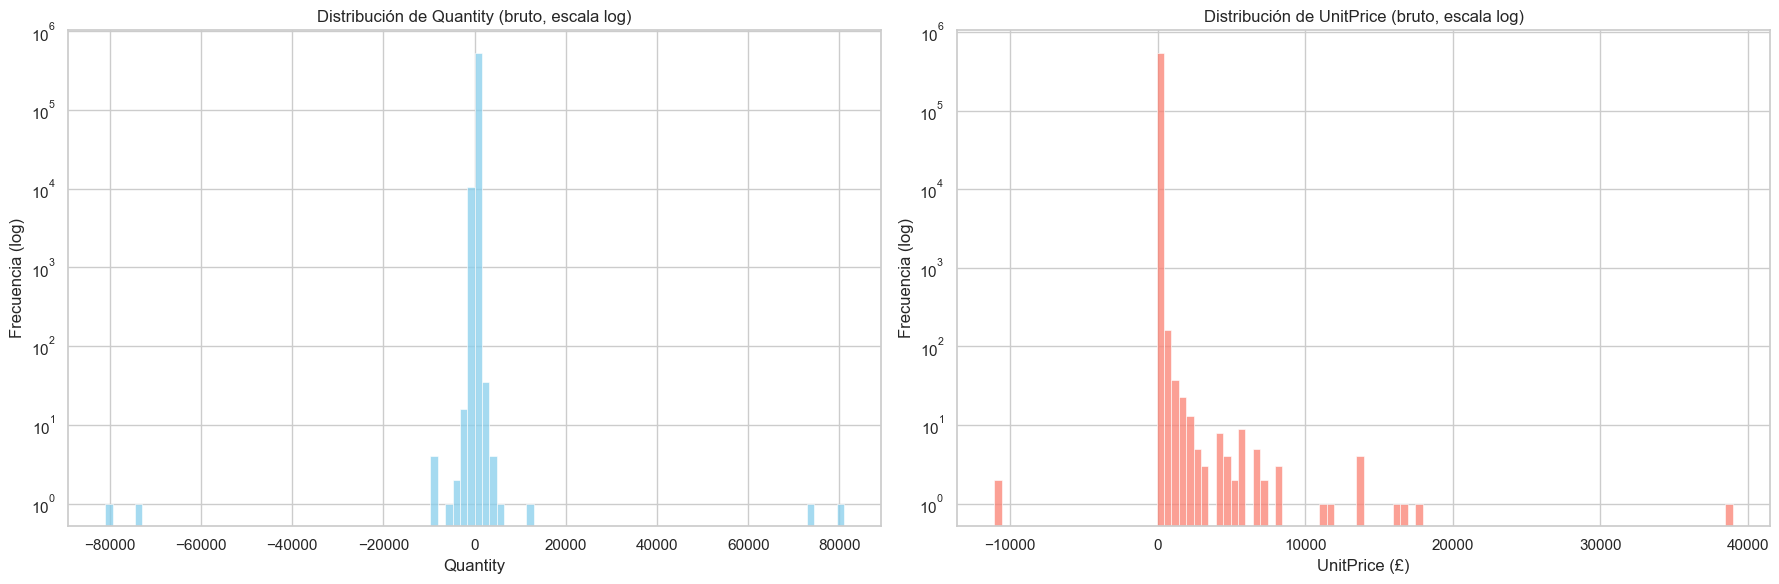

In [39]:
# 2.3.8 — Histogramas brutos de Quantity y UnitPrice (escala logarítmica)
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(df['Quantity'], bins=100, ax=ax[0], color='skyblue', kde=False)
ax[0].set_title('Distribución de Quantity (bruto, escala log)')
ax[0].set_xlabel('Quantity')
ax[0].set_ylabel('Frecuencia (log)')
ax[0].set_yscale('log')

sns.histplot(df['UnitPrice'], bins=100, ax=ax[1], color='salmon', kde=False)
ax[1].set_title('Distribución de UnitPrice (bruto, escala log)')
ax[1].set_xlabel('UnitPrice (£)')
ax[1].set_ylabel('Frecuencia (log)')
ax[1].set_yscale('log')

plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.3.8_histogramas_brutos.png', dpi=150)
plt.show()

In [ ]:
# [DOC] Por un lado hacemos otra gráfica para detectar el top 10 de los países por número de transacciones y por otro lado otra gráfica de top 20 de lcientes por transacciones.

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# [DOC] Top 10 países por transacciones.
df['Country'].value_counts().head(10).plot(kind='bar', ax=ax[0], color='teal')
ax[0].set_title('Top 10 Países con más actividad')
ax[0].set_ylabel('Número de Transacciones')

# [DOC] Top 20 clientes por transacciones.
customer_counts = df['CustomerID'].value_counts().head(20)
customer_counts.plot(kind='bar', ax=ax[1], color='orange')
ax[1].set_title('Top 20 Clientes más activos')
ax[1].set_ylabel('Transacciones por ID')

plt.tight_layout()
plt.show()